# Pre-processing of Synthea for LLOS Prediction

Adapts the MIMIC IV preprocessing pipeline for Synthea data using SNOMED codes directly.
Target: Predict Long Length of Stay (LLOS = LOS ≥ mean + 2σ)

In [2]:
# Paths configuration
from config_utils import load_data_paths

data_paths = load_data_paths()
synthea_path = str(data_paths.raw_csv_dir)
notes_path = str(data_paths.notes_dir)
output_path = str(data_paths.processed_dir)

print(f"Raw CSV dir: {synthea_path}")
print(f"Notes dir: {notes_path}")
print(f"Processed dir: {output_path}")

Raw CSV dir: /Users/william/Documents/LLOS/data/csv
Notes dir: /Users/william/Documents/LLOS/data/notes
Processed dir: /Users/william/Documents/LLOS/data/processed


## 1. Physical characteristics extraction and LOS calculation
Filter to inpatient encounters only, calculate LOS, create LLOS binary label

In [3]:
import pandas as pd
import numpy as np

# Load Synthea data
encounters_df = pd.read_csv(f"{synthea_path}/encounters.csv")
patients_df = pd.read_csv(f"{synthea_path}/patients.csv")

print("Encounters shape:", encounters_df.shape)
print("Patients shape:", patients_df.shape)
print("\nEncounter classes:", encounters_df['ENCOUNTERCLASS'].value_counts())

Encounters shape: (13541533, 15)
Patients shape: (230023, 28)

Encounter classes: ENCOUNTERCLASS
ambulatory    7486949
wellness      2801759
outpatient    1738558
urgentcare     608754
emergency      509367
inpatient      220678
home            74868
snf             33996
virtual         33466
hospice         33138
Name: count, dtype: int64


In [4]:
# Filter to inpatient encounters only (these have meaningful multi-day LOS)
df_enc = encounters_df[encounters_df['ENCOUNTERCLASS'] == 'inpatient'].copy()
print(f"Inpatient encounters: {len(df_enc)}")

# Rename columns to match MIMIC format
df_enc = df_enc.rename(columns={
    'Id': 'hadm_id',
    'PATIENT': 'subject_id',
    'ENCOUNTERCLASS': 'admission_type',
    'START': 'admittime',
    'STOP': 'dischtime',
    'REASONCODE': 'reason_code',
    'REASONDESCRIPTION': 'reason_description'
})

# Merge with patient demographics
patients_df = patients_df.rename(columns={
    'Id': 'subject_id',
    'GENDER': 'gender',
    'RACE': 'race',
    'ETHNICITY': 'ethnicity',
    'MARITAL': 'marital_status',
    'BIRTHDATE': 'birthdate'
})

df_phy_ad = pd.merge(
    df_enc[['subject_id', 'hadm_id', 'admission_type', 'admittime', 'dischtime', 'reason_code', 'reason_description']],
    patients_df[['subject_id', 'gender', 'race', 'ethnicity', 'marital_status', 'birthdate']],
    on='subject_id',
    how='left'
)

print(f"Merged shape: {df_phy_ad.shape}")

Inpatient encounters: 220678
Merged shape: (220678, 12)


In [5]:
df_phy_ad.head()

,subject_id,hadm_id,admission_type,admittime,dischtime,reason_code,reason_description,gender,race,ethnicity,marital_status,birthdate
0,e74367bd-7385-97dc-2c7f-251b4cd9fe29,e74367bd-7385-97dc-25dc-c65de807bce6,inpatient,1996-02-17T22:26:11Z,1996-02-18T22:26:11Z,183996000.0,Sterilization requested (situation),F,white,nonhispanic,D,1960-03-30
1,e74367bd-7385-97dc-2c7f-251b4cd9fe29,e74367bd-7385-97dc-28ba-048203d61460,inpatient,2017-01-25T12:24:27Z,2017-01-28T20:43:34Z,254837009.0,Malignant neoplasm of breast (disorder),F,white,nonhispanic,D,1960-03-30
2,aa616abe-1761-0c9a-7959-07544679dafd,aa616abe-1761-0c9a-b989-935805c83f96,inpatient,1993-06-09T14:28:50Z,1993-06-10T14:28:50Z,183996000.0,Sterilization requested (situation),F,asian,nonhispanic,M,1958-05-21
3,c86c400e-ff88-a1e3-2e23-caa4d8311f47,c86c400e-ff88-a1e3-256c-337eca6ea207,inpatient,2012-11-13T14:45:57Z,2012-11-15T13:24:32Z,363406005.0,Malignant neoplasm of colon (disorder),M,white,hispanic,M,1946-09-06
4,aa616abe-1761-0c9a-7959-07544679dafd,aa616abe-1761-0c9a-68e2-44aedfe6691f,inpatient,2023-02-22T13:40:21Z,2023-02-26T17:20:12Z,254837009.0,Malignant neoplasm of breast (disorder),F,asian,nonhispanic,M,1958-05-21


In [6]:
# Calculate LOS in days
df_phy_ad['admittime'] = pd.to_datetime(df_phy_ad['admittime'], utc=True)
df_phy_ad['dischtime'] = pd.to_datetime(df_phy_ad['dischtime'], utc=True)
df_phy_ad = df_phy_ad.dropna(subset=['admittime', 'dischtime']).copy()

df_phy_ad['LOS'] = (df_phy_ad['dischtime'] - df_phy_ad['admittime']).dt.total_seconds() / (3600 * 24)
df_phy_ad['LOS'] = df_phy_ad['LOS'].round(6)

# Calculate age at admission (handle timezone-aware/naive mismatch)
df_phy_ad['birthdate'] = pd.to_datetime(df_phy_ad['birthdate'], utc=True)
df_phy_ad['anchor_age'] = ((df_phy_ad['admittime'] - df_phy_ad['birthdate']).dt.days / 365.25).astype(int)

# Filter reasonable LOS (0-500 days like MIMIC pipeline)
condition = (df_phy_ad['LOS'] >= 0) & (df_phy_ad['LOS'] <= 500)
df_phy_ad = df_phy_ad[condition]

print(f"After LOS filter: {len(df_phy_ad)} encounters")
print(f"\nLOS statistics:")
print(df_phy_ad['LOS'].describe())

After LOS filter: 220677 encounters

LOS statistics:
count    220677.000000
mean          4.712960
std           4.788131
min           1.000000
25%           1.000000
50%           3.368750
75%           6.469444
max         165.566667
Name: LOS, dtype: float64


In [7]:
# Numeric mapping for categorical variables (Synthea-specific values)
gender_nums = {'F': 1, 'M': 2}
race_nums = {'white': 1, 'black': 2, 'asian': 3, 'native': 4, 'other': 5}
marital_nums = {'S': 1, 'M': 2, 'D': 3, 'W': 4}  # Single, Married, Divorced, Widowed
admission_nums = {'inpatient': 1, 'emergency': 2, 'urgentcare': 3, 'ambulatory': 4, 'wellness': 5, 'outpatient': 6}

# Apply mappings
df_phy_ad['gender'] = df_phy_ad['gender'].map(gender_nums).fillna(0).astype(int)
df_phy_ad['race'] = df_phy_ad['race'].str.lower().map(race_nums).fillna(0).astype(int)
df_phy_ad['marital_status'] = df_phy_ad['marital_status'].map(marital_nums).fillna(0).astype(int)
df_phy_ad['admission_type'] = df_phy_ad['admission_type'].str.lower().map(admission_nums).fillna(0).astype(int)

print("Gender distribution:", df_phy_ad['gender'].value_counts().to_dict())
print("Race distribution:", df_phy_ad['race'].value_counts().to_dict())

Gender distribution: {2: 124929, 1: 95748}
Race distribution: {1: 182854, 2: 18760, 3: 13458, 5: 2269, 0: 2010, 4: 1326}


In [8]:
# Calculate LLOS threshold (mean + 2σ) from the full inpatient population
los_mean = df_phy_ad['LOS'].mean()
los_std = df_phy_ad['LOS'].std()
los_threshold = los_mean + 2 * los_std

print(f"LOS mean:                  {los_mean:.2f} days")
print(f"LOS std:                   {los_std:.2f} days")
print(f"LLOS threshold (mean+2σ):  {los_threshold:.2f} days")
print(f"\nEncounters with LOS >= threshold: {(df_phy_ad['LOS'] >= los_threshold).sum()} "
      f"({(df_phy_ad['LOS'] >= los_threshold).mean()*100:.1f}% of all inpatient encounters)")


LOS mean:                  4.71 days
LOS std:                   4.79 days
LLOS threshold (mean+2σ):  14.29 days

Encounters with LOS >= threshold: 8420 (3.8% of all inpatient encounters)


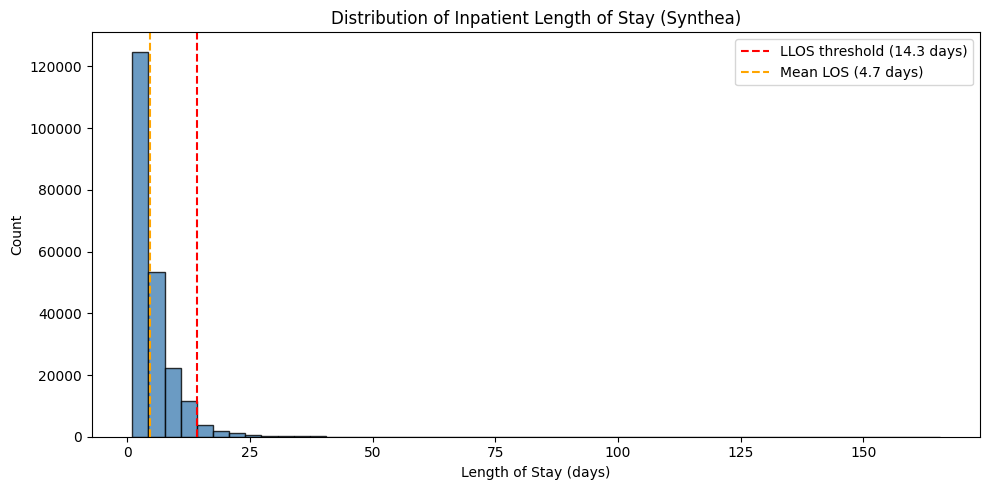

Saved histogram to /Users/william/Documents/LLOS/data/processed/los_histogram.png


In [9]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_phy_ad['LOS'], bins=50, edgecolor='black', color='steelblue', alpha=0.8)
ax.axvline(los_threshold, color='red', linestyle='--', linewidth=1.5, label=f'LLOS threshold ({los_threshold:.1f} days)')
ax.axvline(los_mean, color='orange', linestyle='--', linewidth=1.5, label=f'Mean LOS ({los_mean:.1f} days)')
ax.set_xlabel('Length of Stay (days)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Inpatient Length of Stay (Synthea)')
ax.legend()
plt.tight_layout()

hist_path = f"{output_path}/los_histogram.png"
fig.savefig(hist_path, dpi=150)
plt.show()
print(f"Saved histogram to {hist_path}")


In [10]:
# Filter dataset to LLOS patients only (LOS >= threshold)
# All further steps only concern this high-acuity cohort;
# the regression target is their actual LOS value.
n_before = len(df_phy_ad)
df_phy_ad = df_phy_ad[df_phy_ad['LOS'] >= los_threshold].copy()
n_after = len(df_phy_ad)

print(f"Before LLOS filter: {n_before} encounters")
print(f"After  LLOS filter: {n_after} encounters  ({n_after/n_before*100:.1f}% retained)")
print(f"\nLOS statistics for LLOS cohort:")
print(df_phy_ad['LOS'].describe())


Before LLOS filter: 220677 encounters
After  LLOS filter: 8420 encounters  (3.8% retained)

LOS statistics for LLOS cohort:
count    8420.000000
mean       20.628897
std         8.053342
min        14.290278
25%        16.000000
50%        18.000000
75%        22.052083
max       165.566667
Name: LOS, dtype: float64


In [11]:
# Save physical + admission data (LLOS cohort only; LOS is the regression target)
cols_to_save = ['subject_id', 'hadm_id', 'admission_type', 'marital_status', 'race',
                'gender', 'anchor_age', 'admittime', 'dischtime', 'LOS']
df_phy_ad[cols_to_save].to_csv(f"{output_path}/phy_ad.csv", index=False)

print(f"Saved {len(df_phy_ad)} LLOS encounters to phy_ad.csv")
print(f"Unique patients: {df_phy_ad['subject_id'].nunique()}")


Saved 8420 LLOS encounters to phy_ad.csv
Unique patients: 6541


## 2. Diagnosis SNOMED codes one-hot encoding

In [12]:
import pandas as pd

df_phy = pd.read_csv(f"{output_path}/phy_ad.csv")
conditions_df = pd.read_csv(f"{synthea_path}/conditions.csv")

print("Conditions shape:", conditions_df.shape)
print(conditions_df.head())

Conditions shape: (8335480, 7)
        START        STOP                               PATIENT  \
0  2017-09-22  2017-09-22  76b20010-c318-5754-8c85-983aa538522f   
1  2017-10-27  2017-12-29  76b20010-c318-5754-8c85-983aa538522f   
2  2018-01-05  2018-01-21  76b20010-c318-5754-8c85-983aa538522f   
3  2018-03-02  2018-06-01  76b20010-c318-5754-8c85-983aa538522f   
4  2018-08-31  2018-11-30  76b20010-c318-5754-8c85-983aa538522f   

                              ENCOUNTER     SYSTEM       CODE  \
0  76b20010-c318-5754-57e2-651f596ddb8c  SNOMED-CT  314529007   
1  76b20010-c318-5754-d83c-7cf85a83d079  SNOMED-CT  314529007   
2  76b20010-c318-5754-8283-493693157ccd  SNOMED-CT   10509002   
3  76b20010-c318-5754-86a2-535ab39ce5ad  SNOMED-CT  314529007   
4  76b20010-c318-5754-e480-f6e1ced02a7a  SNOMED-CT  314529007   

                         DESCRIPTION  
0  Medication review due (situation)  
1  Medication review due (situation)  
2        Acute bronchitis (disorder)  
3  Medication revie

In [13]:
# Rename columns to match our format
df_cond = conditions_df.rename(columns={
    'PATIENT': 'subject_id',
    'ENCOUNTER': 'hadm_id',
    'CODE': 'snomed_code',
    'DESCRIPTION': 'description'
})

# Keep only conditions from our filtered encounters
keep_keys = df_phy[['subject_id', 'hadm_id']].drop_duplicates()
df_cond = df_cond.merge(keep_keys, on=['subject_id', 'hadm_id'], how='inner')

# Clean SNOMED codes
df_cond['snomed_code'] = df_cond['snomed_code'].astype(str).str.strip()
df_cond = df_cond.drop_duplicates(subset=['subject_id', 'hadm_id', 'snomed_code'])

print(f"Filtered conditions: {len(df_cond)}")
print(f"Unique SNOMED codes: {df_cond['snomed_code'].nunique()}")

Filtered conditions: 1261
Unique SNOMED codes: 18


In [14]:
# One-hot encode SNOMED diagnosis codes
dummies = pd.get_dummies(df_cond['snomed_code'], prefix='d', dtype='uint8')

cond_sparse = pd.concat([df_cond[['subject_id', 'hadm_id']].reset_index(drop=True), dummies], axis=1)
df_cond_encoded = cond_sparse.groupby(['subject_id', 'hadm_id'], sort=False).max().reset_index()

print(f"One-hot encoded diagnoses shape: {df_cond_encoded.shape}")

One-hot encoded diagnoses shape: (1257, 20)


In [15]:
# Merge with physical characteristics
merged_df = pd.merge(df_phy, df_cond_encoded, on=['subject_id', 'hadm_id'], how='left')

d_cols = [c for c in merged_df.columns if c.startswith('d_')]
if d_cols:
    merged_df[d_cols] = merged_df[d_cols].fillna(0).astype('uint8')

print(f"Final merged shape: {merged_df.shape}")
merged_df.to_csv(f"{output_path}/phyad_dicd.csv", index=False)
print("Saved phyad_dicd.csv")

Final merged shape: (8420, 28)
Saved phyad_dicd.csv


## 3. Procedure SNOMED codes one-hot encoding

In [16]:
import pandas as pd

df_phyad_dicd = pd.read_csv(f"{output_path}/phyad_dicd.csv")
procedures_df = pd.read_csv(f"{synthea_path}/procedures.csv")

print("Loaded diagnosis-merged dataset:", df_phyad_dicd.shape)
print("Procedures shape:", procedures_df.shape)

Loaded diagnosis-merged dataset: (8420, 28)
Procedures shape: (37530228, 10)


In [17]:
# Rename and filter procedures
df_proc = procedures_df.rename(columns={
    'PATIENT': 'subject_id',
    'ENCOUNTER': 'hadm_id',
    'CODE': 'snomed_code',
    'DESCRIPTION': 'description'
})

keep_keys_proc = df_phyad_dicd[['subject_id', 'hadm_id']].drop_duplicates()
df_proc = df_proc.merge(keep_keys_proc, on=['subject_id', 'hadm_id'], how='inner')

df_proc['snomed_code'] = df_proc['snomed_code'].astype(str).str.strip()
df_proc = df_proc.drop_duplicates(subset=['subject_id', 'hadm_id', 'snomed_code'])

print(f"Filtered procedures: {len(df_proc)}")
print(f"Unique procedure codes: {df_proc['snomed_code'].nunique()}")

Filtered procedures: 12014
Unique procedure codes: 35


In [18]:
# One-hot encode procedure codes
p_dummies = pd.get_dummies(df_proc['snomed_code'], prefix='p', dtype='uint8')

proc_block = pd.concat([df_proc[['subject_id', 'hadm_id']].reset_index(drop=True), p_dummies], axis=1)
df_proc_encoded = proc_block.groupby(['subject_id', 'hadm_id'], sort=False).max().reset_index()

print(f"Procedures one-hot encoded shape: {df_proc_encoded.shape}")

Procedures one-hot encoded shape: (4475, 37)


In [19]:
# Merge with existing data
merged_df = df_phyad_dicd.merge(df_proc_encoded, on=['subject_id', 'hadm_id'], how='left')

p_cols = [c for c in merged_df.columns if c.startswith('p_')]
if p_cols:
    merged_df[p_cols] = merged_df[p_cols].fillna(0).astype('uint8')

print(f"Final merged shape: {merged_df.shape}")
merged_df.to_csv(f"{output_path}/phyad_dicd_picd.csv", index=False)
print("Saved phyad_dicd_picd.csv")

Final merged shape: (8420, 63)
Saved phyad_dicd_picd.csv


## 4. Medication frequency processing (RxNorm codes)

In [20]:
import pandas as pd
import re

df_other = pd.read_csv(f"{output_path}/phyad_dicd_picd.csv")
medications_df = pd.read_csv(f"{synthea_path}/medications.csv")

print("Medications shape:", medications_df.shape)
print(medications_df.columns.tolist())

Medications shape: (11534336, 13)
['START', 'STOP', 'PATIENT', 'PAYER', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'BASE_COST', 'PAYER_COVERAGE', 'DISPENSES', 'TOTALCOST', 'REASONCODE', 'REASONDESCRIPTION']


In [21]:
# Rename and filter medications
df_med = medications_df.rename(columns={
    'PATIENT': 'subject_id',
    'ENCOUNTER': 'hadm_id',
    'CODE': 'rxnorm_code',
    'DESCRIPTION': 'drug',
    'DISPENSES': 'dispenses',
    'TOTALCOST': 'total_cost',
    'START': 'start_time',
    'STOP': 'stop_time'
})

# Keep only medications from our filtered encounters
valid_pairs = df_other[['subject_id', 'hadm_id']].drop_duplicates()
df_med = df_med.merge(valid_pairs, on=['subject_id', 'hadm_id'], how='inner')

print(f"Filtered medications: {len(df_med)}")

Filtered medications: 113198


In [22]:
# Calculate medication frequency from dispenses and duration
df_med['start_time'] = pd.to_datetime(df_med['start_time'])
df_med['stop_time'] = pd.to_datetime(df_med['stop_time'])

# Duration in days
df_med['duration_days'] = (df_med['stop_time'] - df_med['start_time']).dt.total_seconds() / (3600 * 24)
df_med['duration_days'] = df_med['duration_days'].clip(lower=1)  # Minimum 1 day

# Approximate daily frequency
df_med['dispenses'] = df_med['dispenses'].fillna(1)
df_med['freq_per_day'] = (df_med['dispenses'] / df_med['duration_days']).clip(upper=24)

# Map to frequency codes (similar to MIMIC pipeline)
def freq_to_code(freq):
    try:
        freq = float(freq)
        if freq <= 0: return 0
        elif freq <= 1: return 1  # OD
        elif freq <= 2: return 2  # BID
        elif freq <= 3: return 3  # TID
        elif freq <= 4: return 4  # QID
        elif freq <= 6: return 6  # Q4H
        elif freq <= 8: return 8  # Q3H
        elif freq <= 12: return 12  # Q2H
        else: return 24  # Q1H
    except:
        return 0

df_med['freq_code'] = df_med['freq_per_day'].apply(freq_to_code)

In [23]:
# Create medication identifier (RxNorm code)
df_med['med_id'] = 'rx_' + df_med['rxnorm_code'].astype(str)

# Build frequency matrix
freq_grouped = df_med.groupby(['subject_id', 'hadm_id', 'med_id'])['freq_code'].max().reset_index()
freq_matrix = freq_grouped.pivot(index=['subject_id', 'hadm_id'], columns='med_id', values='freq_code')\
                          .fillna(0).astype(int).reset_index()

print(f"Medication frequency matrix shape: {freq_matrix.shape}")
freq_matrix.to_csv(f"{output_path}/med_freq_matrix.csv", index=False)

Medication frequency matrix shape: (3515, 32)


In [24]:
# Merge with existing data
df_data = pd.read_csv(f"{output_path}/phyad_dicd_picd.csv")
df_med_matrix = pd.read_csv(f"{output_path}/med_freq_matrix.csv")

merged_df = pd.merge(df_data, df_med_matrix, on=['subject_id', 'hadm_id'], how='left')
merged_df = merged_df.fillna(0)

print(f"Final merged shape: {merged_df.shape}")
merged_df.to_csv(f"{output_path}/phyad_dicd_picd_medfreq.csv", index=False)
print("Saved phyad_dicd_picd_medfreq.csv")

Final merged shape: (8420, 93)
Saved phyad_dicd_picd_medfreq.csv


## 5. Chief Complaint extraction from Synthea notes

In [25]:
import pandas as pd
import re
import os
from pathlib import Path

df_other = pd.read_csv(f"{output_path}/phyad_dicd_picd_medfreq.csv")

# Load all Synthea notes
notes_files = list(Path(notes_path).glob("*.txt"))
print(f"Found {len(notes_files)} note files")

Found 230023 note files


In [26]:
def extract_patient_id_from_filename(filename):
    """Extract patient UUID from Synthea note filename.
    Format: FirstName_LastName_UUID.txt
    """
    name = filename.stem
    parts = name.split('_')
    if len(parts) >= 3:
        # UUID is the last part (may contain hyphens)
        return '_'.join(parts[2:]) if len(parts) > 3 else parts[2]
    return None

def split_note_into_encounter_blocks(note_text):
    """Split a Synthea note file into per-encounter blocks by date header.
    
    Each encounter in a note file starts with a date line (YYYY-MM-DD).
    Returns a list of (date_str, block_text) tuples.
    """
    if not isinstance(note_text, str) or not note_text.strip():
        return []
    
    # Split on date lines: standalone YYYY-MM-DD on its own line
    date_pattern = re.compile(r'^\s*(\d{4}-\d{2}-\d{2})\s*$', re.MULTILINE)
    
    blocks = []
    matches = list(date_pattern.finditer(note_text))
    
    for i, match in enumerate(matches):
        date_str = match.group(1)
        start = match.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(note_text)
        block_text = note_text[start:end].strip()
        if block_text:
            blocks.append((date_str, block_text))
    
    return blocks

def extract_chief_complaint_synthea(note_text):
    """Extract Chief Complaint from a single encounter block (or full note).
    Synthea uses: # Chief Complaint\nContent\n\n# Next Section
    """
    if not isinstance(note_text, str) or not note_text.strip():
        return "NA"
    
    # Look for markdown header
    match = re.search(r'^#\s*Chief\s+Complaint\s*\n(.+?)(?=^#|\Z)', 
                      note_text, flags=re.MULTILINE | re.IGNORECASE | re.DOTALL)
    
    if match:
        complaint = match.group(1).strip()
        complaint = re.sub(r'\s+', ' ', complaint)
        
        if complaint.lower() in ['no complaints.', 'no complaints', 'none', 'n/a']:
            return "NA"
        
        return complaint if complaint else "NA"
    
    return "NA"

# Test on first file
# if notes_files:
#     sample = notes_files[79].read_text(encoding='utf-8')
#     print("Sample note (first 500 chars):")
#     print(sample[:500])
    
#     # Test new date-aware splitting
#     blocks = split_note_into_encounter_blocks(sample)
#     print(f"\n--- Found {len(blocks)} encounter blocks in this note file ---")
#     for date_str, block in blocks[:3]:
#         cc = extract_chief_complaint_synthea(block)
#         print(f"  Date: {date_str}, CC: {cc[:80]}...")


In [27]:
# Extract chief complaints PER ENCOUNTER BLOCK (date-aware)
cc_records = []

for note_file in notes_files:
    try:
        patient_id = extract_patient_id_from_filename(note_file)
        note_text = note_file.read_text(encoding='utf-8')
        
        blocks = split_note_into_encounter_blocks(note_text)
        
        if not blocks:
            # Fallback: treat entire file as one block with unknown date
            cc = extract_chief_complaint_synthea(note_text)
            cc_records.append({
                'subject_id': patient_id,
                'note_date': None,
                'chief_complaint': cc,
                'filename': note_file.name
            })
        else:
            # If the same date appears multiple times, concatenate blocks before extracting
            from collections import defaultdict
            date_blocks = defaultdict(list)
            for date_str, block_text in blocks:
                date_blocks[date_str].append(block_text)
            
            for date_str, block_texts in date_blocks.items():
                combined_block = "\n\n".join(block_texts)
                cc = extract_chief_complaint_synthea(combined_block)
                cc_records.append({
                    'subject_id': patient_id,
                    'note_date': date_str,
                    'chief_complaint': cc,
                    'filename': note_file.name
                })
    except Exception as e:
        print(f"Error processing {note_file.name}: {e}")

cc_df = pd.DataFrame(cc_records)
print(f"Extracted {len(cc_df)} chief complaint records (per-encounter-block)")
print(f"Unique patients: {cc_df['subject_id'].nunique()}")
print(f"NA rate: {(cc_df['chief_complaint'] == 'NA').mean()*100:.1f}%")


Extracted 13091901 chief complaint records (per-encounter-block)
Unique patients: 230023
NA rate: 50.4%


In [28]:
# Match note blocks to specific encounters using subject_id + admittime date
# This ensures each encounter gets *its own* CC rather than a single per-patient CC.

# Prepare encounter lookup: subject_id + admittime date
df_enc_lookup = df_other[['subject_id', 'hadm_id', 'admittime']].copy()
df_enc_lookup['admittime'] = pd.to_datetime(df_enc_lookup['admittime'], utc=True)
df_enc_lookup['admit_date'] = df_enc_lookup['admittime'].dt.strftime('%Y-%m-%d')

# Prepare note CC lookup
cc_df['note_date'] = cc_df['note_date'].astype(str)

# Merge on subject_id + date match (note_date == admit_date)
cc_matched = cc_df.merge(
    df_enc_lookup[['subject_id', 'hadm_id', 'admit_date']],
    left_on=['subject_id', 'note_date'],
    right_on=['subject_id', 'admit_date'],
    how='inner'
)

# For encounters with no date-matched note, fall back to "NA"
all_encounters = df_other[['subject_id', 'hadm_id']].drop_duplicates()
cc_matched_dedup = cc_matched.drop_duplicates(subset=['subject_id', 'hadm_id'], keep='first')
cc_final_matched = all_encounters.merge(
    cc_matched_dedup[['subject_id', 'hadm_id', 'chief_complaint']],
    on=['subject_id', 'hadm_id'],
    how='left'
)
cc_final_matched['chief_complaint'] = cc_final_matched['chief_complaint'].fillna('NA')

print(f"Total LLOS encounters: {len(all_encounters)}")
print(f"Encounters with date-matched CC: {(cc_final_matched['chief_complaint'] != 'NA').sum()}")
print(f"Encounters without matched CC (fallback NA): {(cc_final_matched['chief_complaint'] == 'NA').sum()}")

cc_final_matched.to_csv(f"{output_path}/chief_complaint_extract.csv", index=False)


Total LLOS encounters: 8420
Encounters with date-matched CC: 3401
Encounters without matched CC (fallback NA): 5019


## 6. Chief Complaint cleaning

In [29]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import pandas as pd
import re

In [30]:
df_cc = pd.read_csv(f"{output_path}/chief_complaint_extract.csv")
complaints = df_cc['chief_complaint'].astype(str).tolist()

stop_words = set(stopwords.words('english'))

# For Synthea, we don't have a medical dictionary, so we'll keep all non-stopwords
cleaned_complaints = []

for line in complaints:
    if pd.isna(line) or not str(line).strip() or line.upper() == 'NA':
        cleaned_complaints.append("")
        continue
    
    tokens = word_tokenize(line.lower())
    tokens = [re.sub(r'\W+', '', t) for t in tokens if t.isalnum()]
    tokens_nostop = [t for t in tokens if t not in stop_words and len(t) > 2]
    
    cleaned_complaints.append(" ".join(sorted(set(tokens_nostop))))

df_cc['cleaned_complaint'] = cleaned_complaints
df_cc.to_csv(f"{output_path}/chief_complaint_cleaned.csv", index=False)

print(f"Cleaned {sum(1 for c in cleaned_complaints if c)} / {len(cleaned_complaints)} complaints")
print(f"Keyed by: subject_id + hadm_id (per-encounter)")


Cleaned 8420 / 8420 complaints
Keyed by: subject_id + hadm_id (per-encounter)


## 7. History of Present Illness extraction

In [31]:
def extract_hpi_synthea(note_text, max_words=200):
    """Extract History of Present Illness from a single encounter block (or full note)."""
    if not isinstance(note_text, str) or not note_text.strip():
        return "NA"
    
    # Look for HPI section
    match = re.search(r'^#\s*History\s+of\s+Present\s+Illness\s*\n(.+?)(?=^#|\Z)', 
                      note_text, flags=re.MULTILINE | re.IGNORECASE | re.DOTALL)
    
    if match:
        hpi = match.group(1).strip()
        words = hpi.split()[:max_words]
        hpi = ' '.join(words)
        hpi = re.sub(r'\s+', ' ', hpi)
        return hpi.lower() if hpi else "NA"
    
    return "NA"

# Extract HPI PER ENCOUNTER BLOCK (date-aware)
from collections import defaultdict

hpi_records = []

for note_file in notes_files:
    try:
        patient_id = extract_patient_id_from_filename(note_file)
        note_text = note_file.read_text(encoding='utf-8')
        
        blocks = split_note_into_encounter_blocks(note_text)
        
        if not blocks:
            hpi = extract_hpi_synthea(note_text)
            hpi_records.append({
                'subject_id': patient_id,
                'note_date': None,
                'hpi': hpi
            })
        else:
            date_blocks = defaultdict(list)
            for date_str, block_text in blocks:
                date_blocks[date_str].append(block_text)
            
            for date_str, block_texts in date_blocks.items():
                combined_block = "\n\n".join(block_texts)
                hpi = extract_hpi_synthea(combined_block)
                hpi_records.append({
                    'subject_id': patient_id,
                    'note_date': date_str,
                    'hpi': hpi
                })
    except Exception as e:
        print(f"Error: {e}")

hpi_df = pd.DataFrame(hpi_records)

# Match HPI to encounters by subject_id + admittime date (same logic as CC)
hpi_df['note_date'] = hpi_df['note_date'].astype(str)

hpi_matched = hpi_df.merge(
    df_enc_lookup[['subject_id', 'hadm_id', 'admit_date']],
    left_on=['subject_id', 'note_date'],
    right_on=['subject_id', 'admit_date'],
    how='inner'
)

all_encounters = df_other[['subject_id', 'hadm_id']].drop_duplicates()
hpi_matched_dedup = hpi_matched.drop_duplicates(subset=['subject_id', 'hadm_id'], keep='first')
hpi_final_matched = all_encounters.merge(
    hpi_matched_dedup[['subject_id', 'hadm_id', 'hpi']],
    on=['subject_id', 'hadm_id'],
    how='left'
)
hpi_final_matched['hpi'] = hpi_final_matched['hpi'].fillna('NA')

print(f"Extracted {len(hpi_df)} HPI records (per-encounter-block)")
print(f"Encounters with date-matched HPI: {(hpi_final_matched['hpi'] != 'NA').sum()}")
print(f"Encounters without matched HPI (fallback NA): {(hpi_final_matched['hpi'] == 'NA').sum()}")

hpi_final_matched.to_csv(f"{output_path}/hpi_extract.csv", index=False)


Extracted 13091901 HPI records (per-encounter-block)
Encounters with date-matched HPI: 6199
Encounters without matched HPI (fallback NA): 2221


In [32]:
# Clean HPI
df_hpi = pd.read_csv(f"{output_path}/hpi_extract.csv")
hpis = df_hpi['hpi'].astype(str).tolist()

cleaned_hpi = []
for line in hpis:
    if pd.isna(line) or not str(line).strip() or line.upper() == 'NA':
        cleaned_hpi.append("")
        continue
    
    tokens = word_tokenize(line.lower())
    tokens = [re.sub(r'\W+', '', t) for t in tokens if t.isalnum()]
    tokens_nostop = [t for t in tokens if t not in stop_words and len(t) > 2]
    
    cleaned_hpi.append(" ".join(sorted(set(tokens_nostop))))

df_hpi['cleaned_hpi'] = cleaned_hpi
df_hpi.to_csv(f"{output_path}/hpi_cleaned.csv", index=False)

print(f"Cleaned {sum(1 for c in cleaned_hpi if c)} / {len(cleaned_hpi)} HPI records")
print(f"Keyed by: subject_id + hadm_id (per-encounter)")


Cleaned 8420 / 8420 HPI records
Keyed by: subject_id + hadm_id (per-encounter)


## 7b. Temporal train/test split (encounter-level, before embedding computation)

Perform the 80/20 temporal split NOW so that Word2Vec trains only on training encounters' text.
This prevents data leakage from test-set vocabulary into learned representations.

In [33]:
import pandas as pd

# Load the structured features to get admittime for all LLOS encounters
df_encounters = pd.read_csv(f"{output_path}/phy_ad.csv")
df_encounters['admittime'] = pd.to_datetime(df_encounters['admittime'], utc=True)

# Temporal split: sort by admittime, first 80% -> train
df_sorted = df_encounters.sort_values('admittime').reset_index(drop=True)
cutoff_idx = int(len(df_sorted) * 0.80)
cutoff_date = df_sorted['admittime'].iloc[cutoff_idx]

split_lookup = df_sorted[['subject_id', 'hadm_id']].copy()
split_lookup['split'] = ['train' if i < cutoff_idx else 'test' for i in range(len(df_sorted))]
split_lookup.to_csv(f"{output_path}/temporal_split_ids.csv", index=False)

print(f"Temporal split cutoff date: {cutoff_date.date()}")
print(f"Train encounters: {(split_lookup['split'] == 'train').sum()}")
print(f"Test encounters:  {(split_lookup['split'] == 'test').sum()}")

Temporal split cutoff date: 2022-07-07
Train encounters: 6736
Test encounters:  1684


## 8. Word2Vec embeddings for CC and HPI (train-only fitting, separate inference)

Word2Vec is trained exclusively on training-set text to prevent data leakage.
Test-set embeddings are computed using the train-fitted model; OOV words get zero vectors.

In [34]:
from gensim.models import Word2Vec
import numpy as np

# Load cleaned text data
df_cc = pd.read_csv(f"{output_path}/chief_complaint_cleaned.csv")
df_hpi = pd.read_csv(f"{output_path}/hpi_cleaned.csv")

# Load split assignment
split_lookup = pd.read_csv(f"{output_path}/temporal_split_ids.csv")

# Tag each text record with train/test
df_cc = df_cc.merge(split_lookup, on=['subject_id', 'hadm_id'], how='left')
df_hpi = df_hpi.merge(split_lookup, on=['subject_id', 'hadm_id'], how='left')

df_cc_train = df_cc[df_cc['split'] == 'train']
df_cc_test  = df_cc[df_cc['split'] == 'test']
df_hpi_train = df_hpi[df_hpi['split'] == 'train']
df_hpi_test  = df_hpi[df_hpi['split'] == 'test']

# Prepare sentences for Word2Vec -- TRAIN SET ONLY
sentences = []

for text in df_cc_train['cleaned_complaint'].dropna():
    if str(text).strip():
        sentences.append(str(text).split())

for text in df_hpi_train['cleaned_hpi'].dropna():
    if str(text).strip():
        sentences.append(str(text).split())

print(f"Training Word2Vec on {len(sentences)} TRAIN-ONLY sentences")
print(f"  CC  train: {len(df_cc_train)}, test: {len(df_cc_test)}")
print(f"  HPI train: {len(df_hpi_train)}, test: {len(df_hpi_test)}")

Training Word2Vec on 7976 TRAIN-ONLY sentences
  CC  train: 6736, test: 1684
  HPI train: 6736, test: 1684


In [35]:
# Train Word2Vec model
embedding_dim = 100

if len(sentences) > 0:
    model = Word2Vec(
        sentences=sentences,
        vector_size=embedding_dim,
        window=5,
        min_count=1,
        workers=4,
        epochs=10
    )
    
    # Save model
    model.wv.save_word2vec_format(f"{output_path}/cc_hpi_embed.txt", binary=False)
    print(f"Trained Word2Vec with vocabulary size: {len(model.wv)}")
else:
    print("Warning: No sentences to train Word2Vec")

Trained Word2Vec with vocabulary size: 2233


In [36]:
# Load embeddings and compute averaged vectors
word_vectors = {}

try:
    with open(f"{output_path}/cc_hpi_embed.txt", "r", encoding="utf-8") as f:
        next(f)  # Skip header line
        for line in f:
            parts = line.strip().split()
            if len(parts) == embedding_dim + 1:
                word = parts[0]
                vector = np.array(parts[1:], dtype=float)
                word_vectors[word] = vector
    print(f"Loaded {len(word_vectors)} word vectors")
except FileNotFoundError:
    print("No embeddings file found - will use zero vectors")

Loaded 2233 word vectors


In [37]:
def average_vector(text, word_vectors, embedding_dim=100):
    if pd.isna(text) or not str(text).strip():
        return np.zeros(embedding_dim)
    
    tokens = str(text).split()
    vectors = [word_vectors[word] for word in tokens if word in word_vectors]
    
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(embedding_dim)

# Compute CC embeddings SEPARATELY for train and test
cc_parts = []
for split_name, df_split in [('train', df_cc_train), ('test', df_cc_test)]:
    df_split = df_split.copy()
    df_split['embedding'] = df_split['cleaned_complaint'].apply(
        lambda x: average_vector(x, word_vectors, embedding_dim)
    )
    cc_embedding_df = pd.DataFrame(df_split['embedding'].tolist(), index=df_split.index)
    cc_embedding_df.columns = [f'cc_embedding_{i}' for i in range(embedding_dim)]
    
    cc_final = pd.concat([df_split[['subject_id', 'hadm_id']].reset_index(drop=True),
                           cc_embedding_df.reset_index(drop=True)], axis=1)
    cc_final.to_csv(f"{output_path}/averaged_cc_embeds_{split_name}.csv", index=False)
    cc_parts.append(cc_final)
    print(f"Saved CC embeddings ({split_name}): {cc_final.shape}")

# Save combined for downstream merge
pd.concat(cc_parts, ignore_index=True).to_csv(f"{output_path}/averaged_cc_embeds.csv", index=False)

Saved CC embeddings (train): (6736, 102)
Saved CC embeddings (test): (1684, 102)


In [38]:
# Compute HPI embeddings SEPARATELY for train and test
hpi_parts = []
for split_name, df_split in [('train', df_hpi_train), ('test', df_hpi_test)]:
    df_split = df_split.copy()
    df_split['embedding'] = df_split['cleaned_hpi'].apply(
        lambda x: average_vector(x, word_vectors, embedding_dim)
    )
    hpi_embedding_df = pd.DataFrame(df_split['embedding'].tolist(), index=df_split.index)
    hpi_embedding_df.columns = [f'hpi_embedding_{i}' for i in range(embedding_dim)]
    
    hpi_final = pd.concat([df_split[['subject_id', 'hadm_id']].reset_index(drop=True),
                            hpi_embedding_df.reset_index(drop=True)], axis=1)
    hpi_final.to_csv(f"{output_path}/averaged_hpi_embeds_{split_name}.csv", index=False)
    hpi_parts.append(hpi_final)
    print(f"Saved HPI embeddings ({split_name}): {hpi_final.shape}")

# Save combined for downstream merge
pd.concat(hpi_parts, ignore_index=True).to_csv(f"{output_path}/averaged_hpi_embeds.csv", index=False)

Saved HPI embeddings (train): (6736, 102)
Saved HPI embeddings (test): (1684, 102)


## 8b. ClinicalBERT embeddings for CC and HPI

Replaces the Word2Vec averaged embeddings with contextual 768-dim ClinicalBERT embeddings.
Uses the raw (pre-cleaning) CC and HPI text so BERT can leverage full sentence structure.
Reuses `preprocess_text` and `embed_texts_cpu` from `clinicalbert_embed.py`.

**Note on data leakage**: ClinicalBERT uses a frozen pretrained model (no fine-tuning on this dataset),
so there is no vocabulary leakage concern. Embeddings are computed identically for train and test.

In [39]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

from clinicalbert_embed import preprocess_text, embed_texts_cpu
import pandas as pd
import numpy as np

# Load raw (pre-cleaning) CC and HPI extracts
df_cc_raw = pd.read_csv(f"{output_path}/chief_complaint_extract.csv")
df_hpi_raw = pd.read_csv(f"{output_path}/hpi_extract.csv")

print(f"CC  records: {len(df_cc_raw)}  |  HPI records: {len(df_hpi_raw)}")
print(f"CC  non-NA:  {(df_cc_raw['chief_complaint'].astype(str).str.upper() != 'NA').sum()}")
print(f"HPI non-NA:  {(df_hpi_raw['hpi'].astype(str).str.upper() != 'NA').sum()}")

/Users/william/Documents/Cowork/LLOS/CarePathways/.venv2/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CC  records: 8420  |  HPI records: 8420
CC  non-NA:  8420
HPI non-NA:  8420


In [40]:
# Embed Chief Complaints with ClinicalBERT
cc_texts = (
    df_cc_raw['chief_complaint']
    .fillna('')
    .astype(str)
    .apply(lambda t: '' if t.upper() == 'NA' else preprocess_text(t))
    .tolist()
)

print(f"Embedding {sum(1 for t in cc_texts if t)} non-empty CC texts with ClinicalBERT...")
cc_embeds = embed_texts_cpu(cc_texts, model_name="medicalai/ClinicalBERT",
                            batch_size=16, max_len=256, pooling="mean")

cc_embed_df = pd.DataFrame(cc_embeds, columns=[f'cc_embedding_{i}' for i in range(cc_embeds.shape[1])])
cc_bert_final = pd.concat([df_cc_raw[['subject_id', 'hadm_id']].reset_index(drop=True), cc_embed_df], axis=1)
cc_bert_final.to_csv(f"{output_path}/clinicalbert_cc_embeds.csv", index=False)
print(f"Saved ClinicalBERT CC embeddings: {cc_bert_final.shape}")

Embedding 3401 non-empty CC texts with ClinicalBERT...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 52798.39it/s]
DistilBertModel LOAD REPORT from: medicalai/ClinicalBERT
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved ClinicalBERT CC embeddings: (8420, 770)


In [41]:
# Embed HPI with ClinicalBERT
hpi_texts = (
    df_hpi_raw['hpi']
    .fillna('')
    .astype(str)
    .apply(lambda t: '' if t.upper() == 'NA' else preprocess_text(t))
    .tolist()
)

print(f"Embedding {sum(1 for t in hpi_texts if t)} non-empty HPI texts with ClinicalBERT...")
hpi_embeds = embed_texts_cpu(hpi_texts, model_name="medicalai/ClinicalBERT",
                             batch_size=16, max_len=256, pooling="mean")

hpi_embed_df = pd.DataFrame(hpi_embeds, columns=[f'hpi_embedding_{i}' for i in range(hpi_embeds.shape[1])])
hpi_bert_final = pd.concat([df_hpi_raw[['subject_id', 'hadm_id']].reset_index(drop=True), hpi_embed_df], axis=1)
hpi_bert_final.to_csv(f"{output_path}/clinicalbert_hpi_embeds.csv", index=False)
print(f"Saved ClinicalBERT HPI embeddings: {hpi_bert_final.shape}")

Embedding 6199 non-empty HPI texts with ClinicalBERT...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 44820.52it/s]
DistilBertModel LOAD REPORT from: medicalai/ClinicalBERT
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved ClinicalBERT HPI embeddings: (8420, 770)


## 9. Final dataset merge

In [42]:
import pandas as pd

# ── Toggle: which text embeddings to use in the final dataset ──
USE_CLINICALBERT = True   # True → ClinicalBERT 768-dim,  False → Word2Vec 100-dim

# Load structured features
df_main = pd.read_csv(f"{output_path}/phyad_dicd_picd_medfreq.csv")

# Load embedding files based on toggle
if USE_CLINICALBERT:
    df_cc_embed  = pd.read_csv(f"{output_path}/clinicalbert_cc_embeds.csv")
    df_hpi_embed = pd.read_csv(f"{output_path}/clinicalbert_hpi_embeds.csv")
    embed_label  = "ClinicalBERT (768-dim)"
else:
    df_cc_embed  = pd.read_csv(f"{output_path}/averaged_cc_embeds.csv")
    df_hpi_embed = pd.read_csv(f"{output_path}/averaged_hpi_embeds.csv")
    embed_label  = "Word2Vec (100-dim, train-fitted)"

print(f"Embedding source: {embed_label}")
print(f"Main data shape: {df_main.shape}")
print(f"CC embeddings shape: {df_cc_embed.shape}")
print(f"HPI embeddings shape: {df_hpi_embed.shape}")

Embedding source: ClinicalBERT (768-dim)
Main data shape: (8420, 93)
CC embeddings shape: (8420, 770)
HPI embeddings shape: (8420, 770)


In [43]:
# Merge CC embeddings (now per-encounter: subject_id + hadm_id)
df_merged = df_main.merge(df_cc_embed, on=['subject_id', 'hadm_id'], how='left')

# Merge HPI embeddings (now per-encounter: subject_id + hadm_id)
df_merged = df_merged.merge(df_hpi_embed, on=['subject_id', 'hadm_id'], how='left')

# Fill NaN embeddings with zeros (encounters with no date-matched note)
embedding_cols = [c for c in df_merged.columns if 'embedding' in c]
df_merged[embedding_cols] = df_merged[embedding_cols].fillna(0.0)

print(f"Final merged shape: {df_merged.shape}")
print(f"Encounters with non-zero CC embeddings:  {(df_merged[[c for c in df_merged.columns if c.startswith('cc_embedding')]].abs().sum(axis=1) > 0).sum()}")
print(f"Encounters with non-zero HPI embeddings: {(df_merged[[c for c in df_merged.columns if c.startswith('hpi_embedding')]].abs().sum(axis=1) > 0).sum()}")


Final merged shape: (8420, 1629)
Encounters with non-zero CC embeddings:  8420
Encounters with non-zero HPI embeddings: 8420


In [44]:
# Save final dataset
df_merged.to_csv(f"{output_path}/final_dataset.csv", index=False)

# Print summary statistics
print("=" * 50)
print("FINAL DATASET SUMMARY  (LLOS cohort)")
print("=" * 50)
print(f"Total encounters: {len(df_merged)}")
print(f"Unique patients: {df_merged['subject_id'].nunique()}")
print(f"Total columns: {len(df_merged.columns)}")
print(f"\nFeature breakdown:")
print(f"  - Demographics: 6 (admission_type, marital_status, race, gender, anchor_age)")
print(f"  - Diagnosis codes (d_*):  {len([c for c in df_merged.columns if c.startswith('d_')])}")
print(f"  - Procedure codes (p_*):  {len([c for c in df_merged.columns if c.startswith('p_')])}")
print(f"  - Medication codes (rx_*): {len([c for c in df_merged.columns if c.startswith('rx_')])}")
print(f"  - CC embeddings:           {len([c for c in df_merged.columns if c.startswith('cc_embedding')])}")
print(f"  - HPI embeddings:          {len([c for c in df_merged.columns if c.startswith('hpi_embedding')])}")
print(f"\nRegression target (LOS) statistics:")
print(df_merged['LOS'].describe().round(2))


FINAL DATASET SUMMARY  (LLOS cohort)
Total encounters: 8420
Unique patients: 6541
Total columns: 1629

Feature breakdown:
  - Demographics: 6 (admission_type, marital_status, race, gender, anchor_age)
  - Diagnosis codes (d_*):  18
  - Procedure codes (p_*):  35
  - Medication codes (rx_*): 30
  - CC embeddings:           768
  - HPI embeddings:          768

Regression target (LOS) statistics:
count    8420.00
mean       20.63
std         8.05
min        14.29
25%        16.00
50%        18.00
75%        22.05
max       165.57
Name: LOS, dtype: float64


## 10. Train/Test split (temporal — first 80% of encounters by admission date → train)


In [45]:
import pandas as pd

df = pd.read_csv(f"{output_path}/final_dataset.csv")
df['admittime'] = pd.to_datetime(df['admittime'], utc=True)

# Load the pre-computed split assignment (from Section 7b)
split_lookup = pd.read_csv(f"{output_path}/temporal_split_ids.csv")
df = df.merge(split_lookup, on=['subject_id', 'hadm_id'], how='left')

# Identify feature columns: exclude IDs, timestamps, target, and split label
exclude_cols = ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'LOS', 'split']
feature_cols = [c for c in df.columns if c not in exclude_cols]

print(f"Total encounters : {len(df)}")
print(f"Feature columns  : {len(feature_cols)}")
print(f"Admission date range: {df['admittime'].min().date()}  →  {df['admittime'].max().date()}")
print(f"\nLOS (regression target) statistics:")
print(df['LOS'].describe())

Total encounters : 8420
Feature columns  : 1624
Admission date range: 1949-08-24  →  2026-04-07

LOS (regression target) statistics:
count    8420.000000
mean       20.628897
std         8.053342
min        14.290278
25%        16.000000
50%        18.000000
75%        22.052083
max       165.566667
Name: LOS, dtype: float64


In [46]:
# Use the temporal split computed in Section 7b (before embedding computation)
train_df = df[df['split'] == 'train'].drop(columns=['split']).copy()
test_df  = df[df['split'] == 'test'].drop(columns=['split']).copy()

cutoff_date = train_df['admittime'].max()

print(f"Cutoff date : {cutoff_date.date()}")
print(f"\nTrain set : {len(train_df)} encounters")
print(f"  Admission range: {train_df['admittime'].min().date()}  →  {train_df['admittime'].max().date()}")
print(f"  LOS mean: {train_df['LOS'].mean():.2f} days")
print(f"\nTest set  : {len(test_df)} encounters")
print(f"  Admission range: {test_df['admittime'].min().date()}  →  {test_df['admittime'].max().date()}")
print(f"  LOS mean: {test_df['LOS'].mean():.2f} days")

Cutoff date : 2022-07-07

Train set : 6736 encounters
  Admission range: 1949-08-24  →  2022-07-07
  LOS mean: 20.44 days

Test set  : 1684 encounters
  Admission range: 2022-07-07  →  2026-04-07
  LOS mean: 21.40 days


In [47]:
# Save train/test splits
train_df.to_csv(f"{output_path}/train_set.csv", index=False)
test_df.to_csv(f"{output_path}/test_set.csv", index=False)

print(f"Saved train_set.csv ({len(train_df)} rows)")
print(f"Saved test_set.csv  ({len(test_df)} rows)")


Saved train_set.csv (6736 rows)
Saved test_set.csv  (1684 rows)


In [ ]:
# Save feature column names for model training
with open(f"{output_path}/feature_columns.txt", 'w') as f:
    f.write('\n'.join(feature_cols))

print(f"Saved {len(feature_cols)} feature column names")
print("\nPreprocessing complete!")

Saved 1624 feature column names

Preprocessing complete! Ready for Deep Patient model training.


: 